# Python Finals Project: Business Finance (Real Estate Economics)
Group Members: [Pamesa, Dawn Andrei - Leader], [Porras, Rogelio], [Viaña, Justine]

## The Business Case: Pandemic Flight & The WFH Shift
In 2020–2022, the sudden rise of remote work severely disrupted standard property valuations. Homebuyers were forced to make a financial choice: pay an astronomical "location premium" for a tiny condo close to central business districts, or move out to the provinces to secure massive space for a fraction of the cost.

Using web-scraped Lamudi real estate data from this exact era, this notebook performs Exploratory Data Analysis (EDA) to historically analyze and quantify this economic shift.




## 1. Handling Custom Text-Based Missing Values
### Objective

The data profiling step showed that the web scraper recorded missing architectural metrics as a literal string text "na" rather than a standard system NaN (Not a Number) value. Leaving string text mixed inside numeric columns causes aggregations to crash. We must explicitly convert these custom strings to official Python null values and safely remove those incomplete rows to stabilize our dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_line_right_to_left(line):
    line = line.strip()
    if not line:
        return None
    if line.startswith('\uFEFF'):
        line = line[1:]
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
        
    try:
        def split_right(s):
            parts = s.rsplit(',', 1)
            return parts[0], parts[1] if len(parts) == 2 else parts[0]
            
        remaining, link = split_right(line)
        remaining, longitude = split_right(remaining)
        remaining, latitude = split_right(remaining)
        remaining, land_area = split_right(remaining)
        remaining, floor_area = split_right(remaining)
        remaining, bath = split_right(remaining)
        remaining, bedrooms = split_right(remaining)
        
        # Price (PHP)
        if remaining.endswith('""'):
            idx = remaining.rfind(',""')
            price = remaining[idx+3:-2]
            remaining = remaining[:idx]
        else:
            remaining, price = split_right(remaining)
            
        # Location
        if remaining.endswith('""'):
            idx = remaining.rfind(',""')
            location = remaining[idx+3:-2]
            remaining = remaining[:idx]
        else:
            remaining, location = split_right(remaining)
            
        description = remaining
        row = [description, location, price, bedrooms, bath, floor_area, land_area, latitude, longitude, link]
        return [x.replace('""', '"') for x in row]
    except Exception:
        return None

# 1. Load: Open and parse lines using custom right-to-left splitter
with open('PH_houses_v2.csv', 'r', encoding='utf-8') as f:
    rows = [parse_line_right_to_left(line) for line in f]
    rows = [r for r in rows if r is not None]

# 2. Build the DataFrame (Header is the first row)
df = pd.DataFrame(rows[1:], columns=rows[0])

# 3. Clean: Remove quotes/commas and convert to numeric types
df['Price (PHP)'] = pd.to_numeric(df['Price (PHP)'].str.replace('"', '').str.replace(',', ''), errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce').fillna(0).astype(int)
df['Bath'] = pd.to_numeric(df['Bath'], errors='coerce').fillna(0).astype(int)

# 4. Filter: Drop rows where critical data is missing
df.dropna(subset=['Price (PHP)', 'Bedrooms', 'Bath', 'Location'], inplace=True)

# 5. Engineering: Create 'Region' category
ncr = ['manila', 'quezon', 'makati', 'pasig', 'taguig', 'mandaluyong', 'pasay', 'paranaque', 'muntinlupa', 'las pinas', 'valenzuela', 'caloocan', 'navotas', 'malabon', 'marikina', 'san juan', 'pateros']
df['Region'] = df['Location'].apply(lambda x: 'Metro Manila' if any(city in str(x).lower() for city in ncr) else 'Provincial')

print(f"Data successfully cleaned. Current shape: {df.shape}")
display(df.head())

Data successfully cleaned. Current shape: (1460, 11)


,Description,Location,Price (PHP),Bedrooms,Bath,Floor_area (sqm),Land_area (sqm),Latitude,Longitude,Link,Region
0,2-Bedroom Unit for Sale in Amisa Private Resid...,"Mactan, Lapu-Lapu",15916180.0,2,2,74,na,10.3051555,124.0112408,https://www.lamudi.com.ph/2-bedroom-unit-for-s...,Provincial
1,1-Bedroom Unit for Sale in Amisa Private Resid...,"Mactan, Lapu-Lapu",8730355.0,1,1,41,na,10.3051555,124.0112408,https://www.lamudi.com.ph/1-bedroom-unit-for-s...,Provincial
2,Offices at The Galleon - Prime Unit (11G) for ...,"San Antonio, Pasig",27448000.0,0,0,82,na,14.588716,121.060009,https://www.lamudi.com.ph/offices-at-the-galle...,Metro Manila
3,1-Bedroom Unit (821) for Sale in Maple at Verd...,"Ugong, Pasig",16011000.0,1,0,58,na,14.588882,121.079016,https://www.lamudi.com.ph/1-bedroom-unit-821-f...,Metro Manila
4,Alice 2 Storey Townhouse For Sale in Lancaster...,"Tapia, General Trias",1935600.0,3,0,40,40,14.35507,120.876425,https://www.lamudi.com.ph/alice-2-storey-townh...,Provincial


C:\Users\Dawn\AppData\Local\Temp\ipykernel_25456\2686111366.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locs.values, y=top_locs.index, ax=axes[0], palette="viridis")
C:\Users\Dawn\AppData\Local\Temp\ipykernel_25456\2686111366.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=chart_df, x='Region', y='Price (PHP)', ax=axes[2],


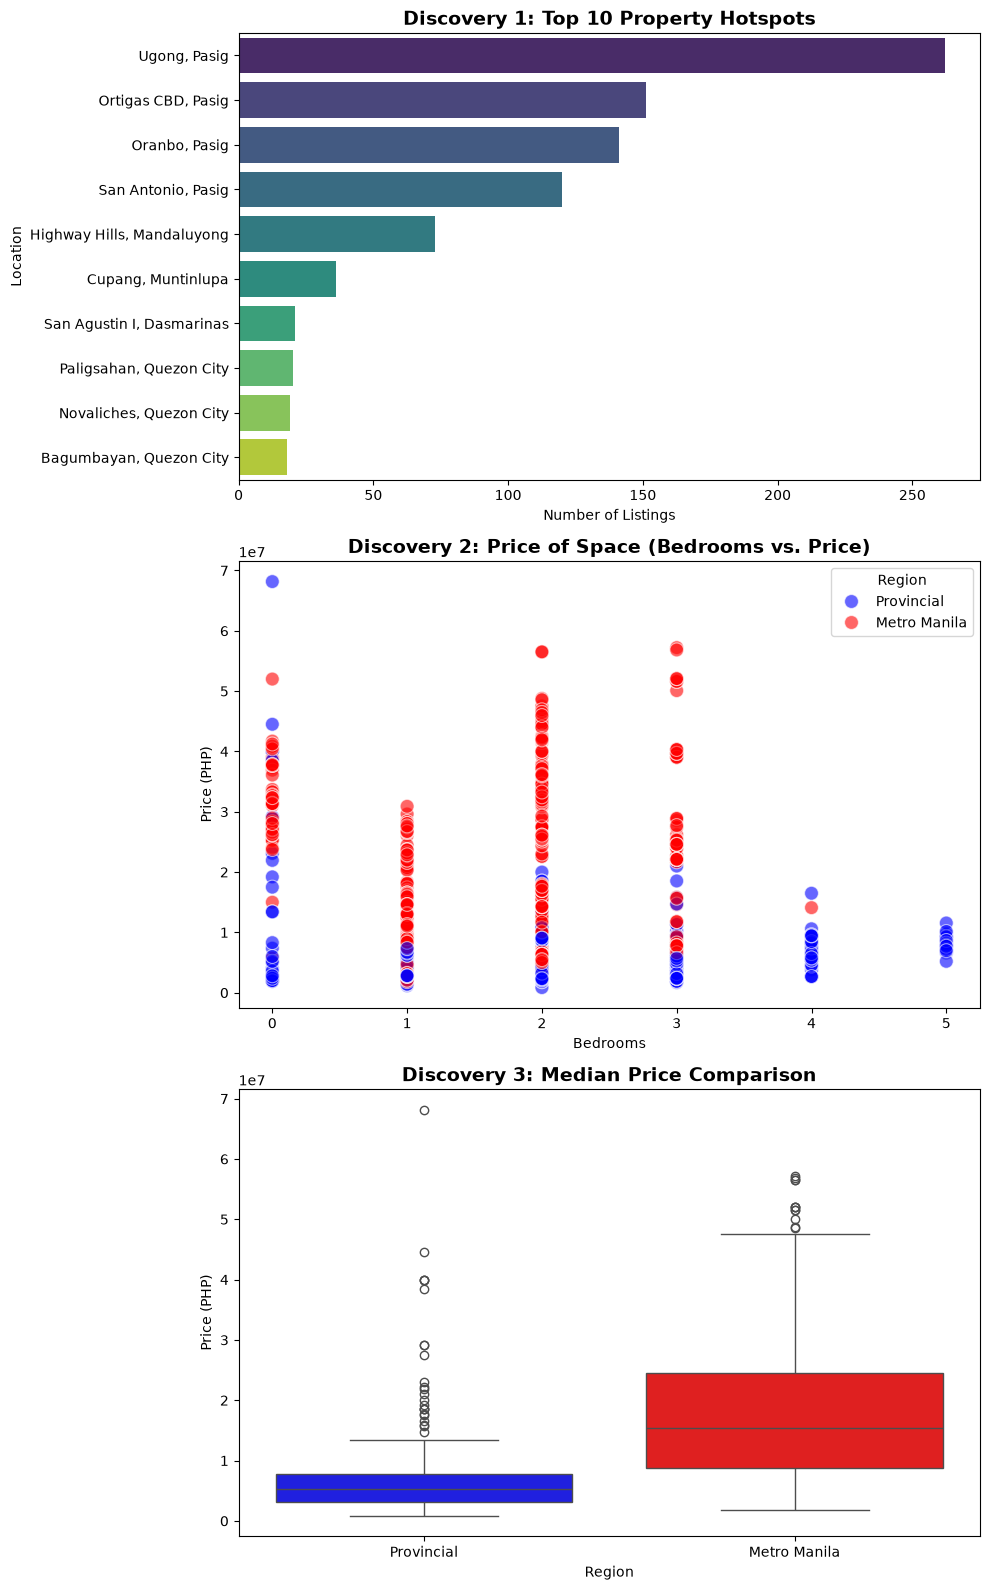

In [4]:
# 1. Prepare filtered data (removing extreme outliers to keep visuals clean)
chart_df = df[df['Price (PHP)'] < 80000000]

# 2. Setup the Plotting Environment
fig, axes = plt.subplots(3, 1, figsize=(10, 16))

# Discovery 1: Top 10 Property Hotspots (Bar Chart)
top_locs = df['Location'].value_counts().head(10)
sns.barplot(x=top_locs.values, y=top_locs.index, ax=axes[0], palette="viridis")
axes[0].set_title('Discovery 1: Top 10 Property Hotspots', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Listings')

# Discovery 2: Price of Space (Scatter Plot)
sns.scatterplot(data=chart_df, x='Bedrooms', y='Price (PHP)', hue='Region', ax=axes[1], 
                palette={'Metro Manila': 'red', 'Provincial': 'blue'}, alpha=0.6, s=100)
axes[1].set_title('Discovery 2: Price of Space (Bedrooms vs. Price)', fontsize=14, fontweight='bold')

# Discovery 3: Urban vs. Provincial Median Prices (Box Plot)
sns.boxplot(data=chart_df, x='Region', y='Price (PHP)', ax=axes[2], 
            palette={'Metro Manila': 'red', 'Provincial': 'blue'})
axes[2].set_title('Discovery 3: Median Price Comparison', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()